# 03 — Difference-in-Differences Analysis

Answers **RQ1** and **RQ2** from the paper:

- **RQ1**: Does exposure to high-engagement negative disclosure posts increase mental health distress in exposed vs. matched unexposed users?
- **RQ2**: Does community breadth moderate this effect?

## Approach
1. **Pre/post windows**: 2 weeks before and 2 weeks after an anchor event week (W-2..W-1 vs W+1..W+2)
2. **Propensity score matching** on pre-event distress + activity level
3. **DiD regression**: `distress ~ post × exposed + controls`
4. **RQ2**: add `post × exposed × community_breadth` interaction

**Input:** `scored_corpus.parquet`, `anchor_posts.parquet`, `exposure_labels.parquet`, `user_weekly_scores.parquet`, `user_community_breadth.parquet`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

ROOT     = Path('..').resolve()
DATA_DIR = ROOT / 'data' / 'processed'
RAW_DIR  = ROOT / 'data' / 'raw'
FIG_DIR  = ROOT / 'figures'
MODEL_DIR = ROOT / 'models'

scored        = pd.read_parquet(DATA_DIR / 'scored_corpus.parquet')
user_weekly   = pd.read_parquet(DATA_DIR / 'user_weekly_scores.parquet')
exposure_df   = pd.read_parquet(DATA_DIR / 'exposure_labels.parquet')
anchor_posts  = pd.read_parquet(DATA_DIR / 'anchor_posts.parquet')
breadth_df    = pd.read_parquet(DATA_DIR / 'user_community_breadth.parquet')

print('Loaded all data')
print(f'  scored: {len(scored):,} | user_weekly: {len(user_weekly):,} | exposure: {len(exposure_df):,}')

Loaded all data
  scored: 467,525 | user_weekly: 210,133 | exposure: 210,133


## 1) Build pre/post panel

For each (author, event_week) exposure record, collect their weekly distress scores in a ±2-week window.

In [2]:
# Convert week strings to ISO-week-offset arithmetic
from datetime import timedelta

def week_str_to_dt(w):
    return pd.to_datetime(w + '-1', format='%G-W%V-%u', utc=True)

def dt_to_week_str(dt):
    return dt.strftime('%G-W%V')

# Build a lookup: (author, week) → distress metrics
uw_lookup = user_weekly.set_index(['author', 'week'])

WINDOW = 2  # weeks before/after

panel_rows = []
for _, row in exposure_df.iterrows():
    author     = row['author']
    event_week = row['event_week']
    exposed    = row['exposed']
    event_dt   = week_str_to_dt(event_week)

    for offset in range(-WINDOW, WINDOW + 1):
        if offset == 0:
            continue  # skip the event week itself
        target_dt   = event_dt + timedelta(weeks=offset)
        target_week = dt_to_week_str(target_dt)
        post_period = offset > 0

        try:
            metrics = uw_lookup.loc[(author, target_week)]
            panel_rows.append({
                'author':        author,
                'event_week':    event_week,
                'target_week':   target_week,
                'offset':        offset,
                'post':          int(post_period),
                'exposed':       int(exposed),
                'mean_distress': metrics['mean_distress'],
                'mean_compound': metrics['mean_compound'],
                'pct_negative':  metrics['pct_negative'],
                'n_posts':       metrics['n_posts'],
            })
        except KeyError:
            pass  # user inactive that week — skip

panel = pd.DataFrame(panel_rows)
print(f'Panel rows: {len(panel):,}')
print(f'Exposed observations: {panel[panel["exposed"]==1].shape[0]:,}')
print(f'Unexposed observations: {panel[panel["exposed"]==0].shape[0]:,}')
panel.head()

Panel rows: 200,646
Exposed observations: 8,471
Unexposed observations: 192,175


,author,event_week,target_week,offset,post,exposed,mean_distress,mean_compound,pct_negative,n_posts
0,crazy-cat-lady_,2025-W24,2025-W26,2,1,1,0.045500,0.962100,0.000000,2
1,Any-Vermicelli-310,2025-W24,2025-W26,2,1,1,0.078667,-0.032733,0.333333,3
2,r21md,2025-W24,2025-W22,-2,0,1,0.000000,0.669550,0.000000,2
3,r21md,2025-W24,2025-W23,-1,0,1,0.018500,0.341675,0.000000,4
4,r21md,2025-W24,2025-W25,1,1,1,0.073700,0.118950,0.300000,10


## 2) Propensity Score Matching

Match exposed and unexposed users on **pre-event** characteristics:
- Pre-event mean distress
- Pre-event post count (activity level)

In [3]:
# Pre-event features for each (author, event_week)
pre_panel = panel[panel['post'] == 0].groupby(['author', 'event_week', 'exposed']).agg(
    pre_distress = ('mean_distress', 'mean'),
    pre_compound = ('mean_compound', 'mean'),
    pre_n_posts  = ('n_posts', 'sum'),
).reset_index()

# Drop rows missing pre-event data
pre_panel = pre_panel.dropna(subset=['pre_distress', 'pre_compound'])

print(f'Pre-panel rows: {len(pre_panel):,}')
print(pre_panel.groupby('exposed')[['pre_distress', 'pre_compound', 'pre_n_posts']].mean().round(4))

Pre-panel rows: 74,018
         pre_distress  pre_compound  pre_n_posts
exposed                                         
0              0.0466        0.3076       4.8664
1              0.0614        0.2118       6.6934


In [4]:
# Estimate propensity scores
features = ['pre_distress', 'pre_compound', 'pre_n_posts']
pre_panel_clean = pre_panel.dropna(subset=features).copy()

scaler = StandardScaler()
X = scaler.fit_transform(pre_panel_clean[features])
y = pre_panel_clean['exposed'].values

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X, y)
pre_panel_clean['pscore'] = lr.predict_proba(X)[:, 1]

print('Propensity score distribution:')
display(pre_panel_clean.groupby('exposed')['pscore'].describe().round(4))

Propensity score distribution:


,count,mean,std,min,25%,50%,75%,max
exposed,,,,,,,,
0,71174.0,0.0383,0.0136,0.0237,0.0307,0.0363,0.0421,0.8523
1,2844.0,0.0424,0.0198,0.0239,0.0333,0.0385,0.0476,0.7248


In [5]:
# Nearest-neighbor matching (1:1, with replacement, caliper=0.05)
from sklearn.neighbors import NearestNeighbors

CALIPER = 0.05

exposed_df   = pre_panel_clean[pre_panel_clean['exposed'] == 1].reset_index(drop=True)
unexposed_df = pre_panel_clean[pre_panel_clean['exposed'] == 0].reset_index(drop=True)

nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(unexposed_df[['pscore']])

dists, indices = nn.kneighbors(exposed_df[['pscore']])

matched_pairs = []
for i, (dist, idx) in enumerate(zip(dists.flatten(), indices.flatten())):
    if dist <= CALIPER:
        matched_pairs.append({
            'exposed_author':   exposed_df.loc[i, 'author'],
            'exposed_week':     exposed_df.loc[i, 'event_week'],
            'unexposed_author': unexposed_df.loc[idx, 'author'],
            'unexposed_week':   unexposed_df.loc[idx, 'event_week'],
            'pscore_exposed':   exposed_df.loc[i, 'pscore'],
            'pscore_unexposed': unexposed_df.loc[idx, 'pscore'],
        })

matched = pd.DataFrame(matched_pairs)
print(f'Matched pairs: {len(matched):,} (caliper={CALIPER})')
matched.head()

Matched pairs: 2,843 (caliper=0.05)


,exposed_author,exposed_week,unexposed_author,unexposed_week,pscore_exposed,pscore_unexposed
0,-Astropunk-,2024-W09,python_with_dr_johns,2025-W06,0.055948,0.055947
1,0372137504321,2024-W44,jar_with_lid,2025-W10,0.029689,0.029689
2,0372137504321,2025-W07,iamanairplaneiswear,2024-W52,0.037365,0.037366
3,100Fishwitharms,2024-W02,Economy-Midnight5300,2024-W04,0.042631,0.042630
4,100Fishwitharms,2024-W04,Quamos_99,2024-W13,0.060838,0.060836


## 3) DiD Panel for matched sample

In [6]:
# Build panel limited to matched users
matched_exposed_keys   = set(zip(matched['exposed_author'],   matched['exposed_week']))
matched_unexposed_keys = set(zip(matched['unexposed_author'], matched['unexposed_week']))

panel['key'] = list(zip(panel['author'], panel['event_week']))
matched_panel = panel[
    panel['key'].isin(matched_exposed_keys | matched_unexposed_keys)
].copy()

print(f'Matched panel rows: {len(matched_panel):,}')
print(matched_panel.groupby(['exposed', 'post'])[['mean_distress', 'mean_compound']].mean().round(4))

Matched panel rows: 12,421
              mean_distress  mean_compound
exposed post                              
0       0            0.0637         0.2162
        1            0.0539         0.2649
1       0            0.0617         0.2126
        1            0.0656         0.2341


## 4) RQ1 — DiD Regression

`distress ~ post + exposed + post*exposed + n_posts`  
Coefficient of interest: `post × exposed` — positive = exposure increases distress

In [7]:
try:
    import statsmodels.formula.api as smf
    HAS_STATSMODELS = True
except ImportError:
    HAS_STATSMODELS = False
    print('statsmodels not available — using sklearn OLS approximation')

if HAS_STATSMODELS:
    # DiD regression: outcome = mean_distress
    did_data = matched_panel.dropna(subset=['mean_distress']).copy()
    did_data['post_x_exposed'] = did_data['post'] * did_data['exposed']

    model_rq1 = smf.ols(
        'mean_distress ~ post + exposed + post_x_exposed + np.log1p(n_posts)',
        data=did_data
    ).fit(cov_type='HC3')  # heteroskedasticity-robust SEs

    print('=== RQ1: DiD on mean_distress ===')
    print(model_rq1.summary2().tables[1].round(4))
    print(f'\nDiD estimate (post×exposed): {model_rq1.params["post_x_exposed"]:.4f}')
    print(f'p-value: {model_rq1.pvalues["post_x_exposed"]:.4f}')
else:
    # Fallback: manual DiD estimate
    cell = matched_panel.groupby(['exposed', 'post'])['mean_distress'].mean()
    DiD = (cell[1,1] - cell[1,0]) - (cell[0,1] - cell[0,0])
    print(f'Manual DiD estimate: {DiD:.4f}')
    print(cell.round(4))

=== RQ1: DiD on mean_distress ===
                    Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
Intercept          0.0657    0.0019  35.4907  0.0000  0.0621  0.0694
post              -0.0098    0.0019  -5.2883  0.0000 -0.0135 -0.0062
exposed           -0.0019    0.0016  -1.1886  0.2346 -0.0051  0.0013
post_x_exposed     0.0137    0.0025   5.4346  0.0000  0.0088  0.0186
np.log1p(n_posts) -0.0015    0.0007  -2.0093  0.0445 -0.0030 -0.0000

DiD estimate (post×exposed): 0.0137
p-value: 0.0000


In [8]:
# Also run on vader_compound (higher = less distressed, so we expect negative DiD)
if HAS_STATSMODELS:
    model_compound = smf.ols(
        'mean_compound ~ post + exposed + post_x_exposed + np.log1p(n_posts)',
        data=did_data
    ).fit(cov_type='HC3')
    print('=== DiD on mean_compound (negative = more distressed) ===')
    print(model_compound.summary2().tables[1].round(4))

=== DiD on mean_compound (negative = more distressed) ===
                    Coef.  Std.Err.        z   P>|z|  [0.025  0.975]
Intercept          0.1844    0.0106  17.3854  0.0000  0.1636  0.2051
post               0.0489    0.0109   4.4792  0.0000  0.0275  0.0702
exposed           -0.0038    0.0093  -0.4067  0.6843 -0.0221  0.0145
post_x_exposed    -0.0278    0.0147  -1.8893  0.0589 -0.0567  0.0010
np.log1p(n_posts)  0.0230    0.0043   5.2942  0.0000  0.0145  0.0315


## 5) Event-study plot (parallel trends check + post-event dynamics)

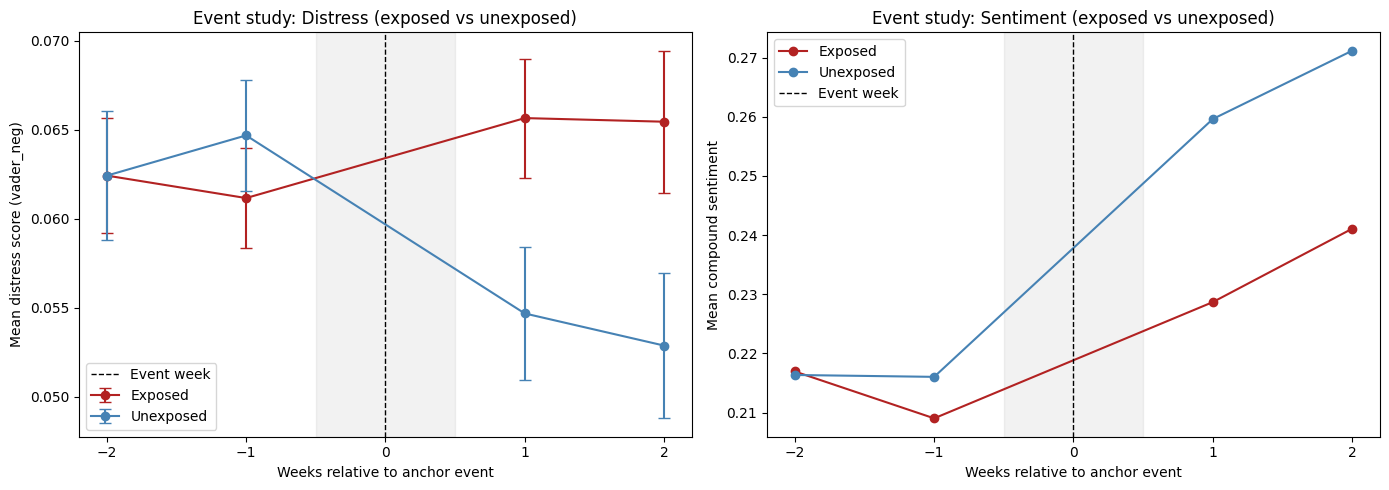

In [9]:
event_study = (
    matched_panel.groupby(['offset', 'exposed'])
    .agg(
        mean_distress = ('mean_distress', 'mean'),
        se_distress   = ('mean_distress', lambda x: x.sem()),
        mean_compound = ('mean_compound', 'mean'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for exposed_val, label, color in [(1, 'Exposed', 'firebrick'), (0, 'Unexposed', 'steelblue')]:
    sub = event_study[event_study['exposed'] == exposed_val]
    
    axes[0].errorbar(
        sub['offset'], sub['mean_distress'],
        yerr=sub['se_distress'] * 1.96,
        label=label, color=color, marker='o', capsize=4
    )
    axes[1].plot(sub['offset'], sub['mean_compound'], label=label, color=color, marker='o')

for ax in axes:
    ax.axvline(0, color='black', linestyle='--', linewidth=1, label='Event week')
    ax.axvspan(-0.5, 0.5, alpha=0.1, color='gray')
    ax.set_xticks(range(-WINDOW, WINDOW+1))
    ax.set_xlabel('Weeks relative to anchor event')
    ax.legend()

axes[0].set_ylabel('Mean distress score (vader_neg)')
axes[0].set_title('Event study: Distress (exposed vs unexposed)')
axes[1].set_ylabel('Mean compound sentiment')
axes[1].set_title('Event study: Sentiment (exposed vs unexposed)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_event_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 6) RQ2 — Community Breadth as Moderator

Requires `community_breadth` from Arctic Shift (currently NaN placeholder).
This cell will run once breadth data is filled in.

In [10]:
# Merge community breadth
did_data_rq2 = did_data.merge(breadth_df[['author', 'community_breadth']], on='author', how='left')
did_data_rq2['breadth_log'] = np.log1p(did_data_rq2['community_breadth'])

n_with_breadth = did_data_rq2['community_breadth'].notna().sum()
print(f'Records with community_breadth data: {n_with_breadth:,} / {len(did_data_rq2):,}')

if n_with_breadth > 100 and HAS_STATSMODELS:
    rq2_data = did_data_rq2.dropna(subset=['breadth_log']).copy()
    rq2_data['triple'] = rq2_data['post_x_exposed'] * rq2_data['breadth_log']

    model_rq2 = smf.ols(
        'mean_distress ~ post + exposed + post_x_exposed + breadth_log '
        '+ post_x_exposed:breadth_log + np.log1p(n_posts)',
        data=rq2_data
    ).fit(cov_type='HC3')

    print('=== RQ2: DiD × Community Breadth ===')
    print(model_rq2.summary2().tables[1].round(4))
    print('\nNegative coefficient on post_x_exposed:breadth_log supports stress-buffering hypothesis.')
else:
    print('\nSkipping RQ2 — community_breadth not yet available.')
    print('Pull Arctic Shift cross-subreddit data and populate user_community_breadth.parquet.')

Records with community_breadth data: 0 / 12,421

Skipping RQ2 — community_breadth not yet available.
Pull Arctic Shift cross-subreddit data and populate user_community_breadth.parquet.


## 7) Temporal seasonality check

Sanity check: distress should peak during peak admissions windows (Dec–Feb).

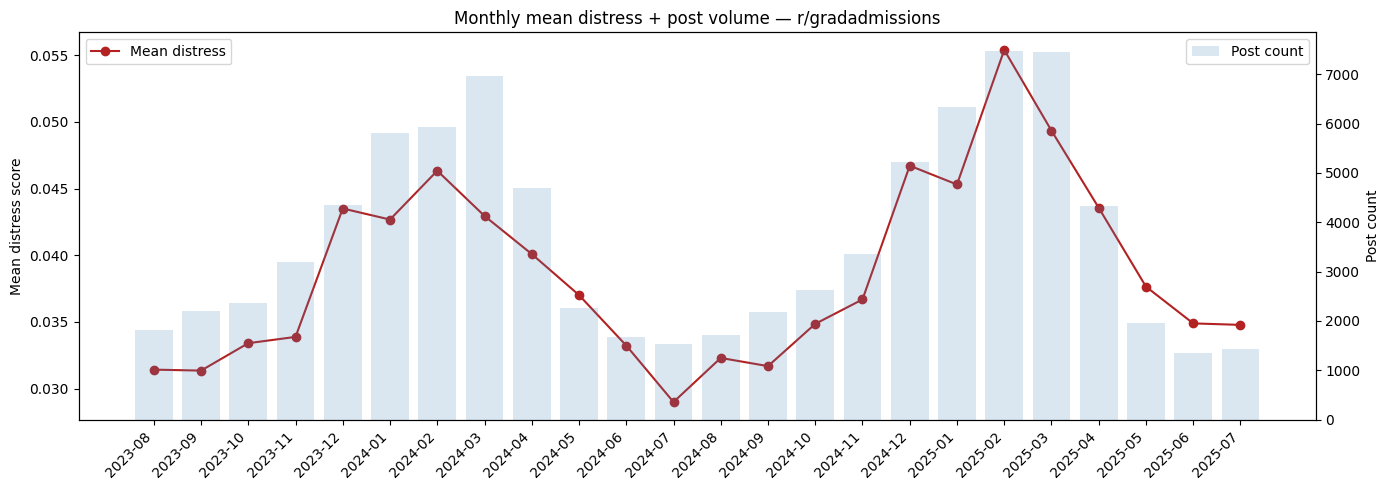


Top 5 most distressed months:


,year_month,mean_distress,mean_compound,n_posts
18,2025-02,0.055390,0.287158,7474
16,2024-12,0.046711,0.291107,5230
6,2024-02,0.046334,0.363384,5926
17,2025-01,0.045303,0.297305,6343
4,2023-12,0.043502,0.323882,4341


In [11]:
monthly = (
    scored[scored['kind'] == 'post']
    .groupby('year_month')
    .agg(
        mean_distress = ('distress_score', 'mean'),
        mean_compound = ('vader_compound', 'mean'),
        n_posts       = ('record_id', 'count')
    )
    .reset_index()
    .sort_values('year_month')
)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(monthly))
ax.plot(x, monthly['mean_distress'], color='firebrick', marker='o', label='Mean distress')
ax2 = ax.twinx()
ax2.bar(x, monthly['n_posts'], alpha=0.2, color='steelblue', label='Post count')

ax.set_xticks(x)
ax.set_xticklabels(monthly['year_month'], rotation=45, ha='right')
ax.set_ylabel('Mean distress score'); ax2.set_ylabel('Post count')
ax.set_title('Monthly mean distress + post volume — r/gradadmissions')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_monthly_distress.png', dpi=150, bbox_inches='tight')
plt.show()

# Expected: distress peaks Dec 2023, Jan/Feb 2024, Dec 2024, Jan/Feb 2025
peak_months = monthly[monthly['year_month'].str.contains(r'-1[012]|-0[12]')].sort_values('mean_distress', ascending=False)
print('\nTop 5 most distressed months:')
display(peak_months.head())

## 8) Cross-cycle replication check

Per paper: replicate analysis across both cycles (2023-24 and 2024-25).

In [12]:
def assign_cycle(week_str):
    dt = pd.to_datetime(week_str + '-1', format='%G-W%V-%u', utc=True)
    if pd.Timestamp('2023-08-01', tz='UTC') <= dt < pd.Timestamp('2024-08-01', tz='UTC'):
        return '2023-24'
    elif pd.Timestamp('2024-08-01', tz='UTC') <= dt < pd.Timestamp('2025-08-01', tz='UTC'):
        return '2024-25'
    return 'other'

matched_panel['cycle'] = matched_panel['event_week'].apply(assign_cycle)

print('DiD estimates by cycle:')
for cycle in ['2023-24', '2024-25']:
    sub = matched_panel[matched_panel['cycle'] == cycle]
    if len(sub) < 50:
        print(f'  {cycle}: insufficient data ({len(sub)} rows)')
        continue
    try:
        cell = sub.groupby(['exposed', 'post'])['mean_distress'].mean()
        DiD = (cell[1,1] - cell[1,0]) - (cell[0,1] - cell[0,0])
        print(f'  {cycle}: DiD = {DiD:.4f}  (n={len(sub):,})')
    except Exception as e:
        print(f'  {cycle}: error — {e}')

DiD estimates by cycle:
  2023-24: DiD = 0.0056  (n=5,438)
  2024-25: DiD = 0.0201  (n=6,983)
